<a href="https://colab.research.google.com/github/njwbilll/midterm-machine-learning/blob/main/1_Transaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Machine Learning — Fraud Detection

| Info | Detail |
|------|--------|
| **Nama** | Najwa Bilqis Al Khalidah |
| **NIM** | 101032300186 |
| **Kelas** | TK-46-GAB |

---

## Tujuan
Membangun pipeline end-to-end machine learning klasifikasi untuk mendeteksi transaksi fraud berdasarkan fitur-fitur transaksi keuangan.

## Alur Pipeline
```
Load Data -> Preprocessing (missing values, encoding, scaling)
    -> Model Training (Logistic Regression, XGBoost+Optuna)
    -> Evaluasi (ROC-AUC, PR-AUC) -> MLflow -> Simpan Model
```

In [ ]:
!pip install optuna mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report,
                             average_precision_score, roc_curve)
import optuna
import mlflow
import mlflow.sklearn
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Library berhasil diimport.")

✅ Done!


## Cell 2 — Load Dataset

Dataset `train_transaction.csv` dimuat dari Google Drive. Untuk menghemat penggunaan RAM, dtype setiap kolom didefinisikan secara eksplisit sebelum proses loading — kolom numerik menggunakan `float32` atau `int32` alih-alih tipe default 64-bit.

Setelah loading, ditampilkan informasi dasar: shape, konsumsi memori, dan fraud rate. Fraud rate yang rendah mengindikasikan class imbalance yang perlu ditangani dalam proses modeling.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/ML Dataset/'

dtype_dict = {
    'TransactionID' : 'int32',
    'isFraud'       : 'int8',
    'TransactionDT' : 'int32',
    'TransactionAmt': 'float32',
    'card1': 'float32', 'card2': 'float32',
    'card3': 'float32', 'card5': 'float32',
    'addr1': 'float32', 'addr2': 'float32',
    'dist1': 'float32', 'dist2': 'float32',
    'C1': 'float32', 'C2': 'float32', 'C3': 'float32',
    'C4': 'float32', 'C5': 'float32', 'C6': 'float32',
    'C7': 'float32', 'C8': 'float32', 'C9': 'float32',
    'C10': 'float32', 'C11': 'float32', 'C12': 'float32',
    'C13': 'float32', 'C14': 'float32',
}

print("Loading data...")
train = pd.read_csv(BASE_PATH + 'train_transaction.csv', dtype=dtype_dict)

print(f"Shape: {train.shape}")
print(f"RAM usage: {train.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Fraud rate: {train['isFraud'].mean()*100:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
✅ Shape: (590540, 394)
RAM usage: 2099.1 MB
Fraud rate: 3.50%


## Cell 3 — Preprocessing

Preprocessing dilakukan dalam beberapa tahap:

1. **Drop kolom dengan missing values tinggi** — kolom dengan lebih dari 75% nilai hilang dihapus karena tidak memiliki cukup informasi untuk diimputasi secara andal.
2. **Feature engineering** — dibuat dua fitur waktu dari `TransactionDT`: jam dalam sehari (`hour`) dan hari dalam seminggu (`day`). Nilai `TransactionAmt` ditransformasi dengan log1p untuk mengurangi skewness. Kolom `TransactionID` dan `TransactionDT` kemudian dihapus karena tidak relevan untuk modeling.
3. **Encoding kolom kategorikal** — setiap kolom bertipe object diisi missing value-nya dengan string `'unknown'`, lalu diencode menggunakan `LabelEncoder`.
4. **Imputasi missing numerik** — nilai yang hilang pada kolom numerik diisi dengan median kolom tersebut.

In [ ]:
missing_rate = train.isnull().mean()
drop_cols = missing_rate[missing_rate > 0.75].index.tolist()
drop_cols = [c for c in drop_cols if c not in ['isFraud', 'TransactionID']]

print(f"Kolom di-drop (missing >75%): {len(drop_cols)}")
train.drop(columns=drop_cols, inplace=True)
print(f"Shape setelah drop: {train.shape}")
print(f"RAM sekarang: {train.memory_usage(deep=True).sum() / 1e6:.1f} MB")

train['TransactionAmt_log'] = np.log1p(train['TransactionAmt']).astype('float32')
train['hour'] = ((train['TransactionDT'] // 3600) % 24).astype('int8')
train['day']  = ((train['TransactionDT'] // (3600*24)) % 7).astype('int8')
train.drop(columns=['TransactionID', 'TransactionDT'], inplace=True)

cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f"\nKolom kategorikal: {cat_cols}")

encoders = {}
for col in cat_cols:
    train[col].fillna('unknown', inplace=True)
    encoders[col] = LabelEncoder()
    train[col] = encoders[col].fit_transform(train[col].astype(str)).astype('int16')

num_cols = train.select_dtypes(include=['float32','float64','int32','int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'isFraud']
for col in num_cols:
    train[col].fillna(train[col].median(), inplace=True)

print(f"\nPreprocessing selesai.")
print(f"RAM sekarang: {train.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Kolom di-drop (missing >75%): 168
Shape setelah drop: (590540, 226)
RAM sekarang: 1289.8 MB

Kolom kategorikal: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

✅ Preprocessing selesai!
RAM sekarang: 959.6 MB


## Cell 4 — Train-Validation Split & Scaling

Data dibagi menjadi training set (80%) dan validation set (20%) dengan stratifikasi pada label `isFraud`, sehingga proporsi fraud terjaga di kedua split.

Setelah split, objek `train` dan array `X` dihapus dari memori untuk membebaskan RAM di Colab. `StandardScaler` di-fit hanya pada training data, kemudian diaplikasikan ke validation set untuk mencegah data leakage. Scaled data digunakan untuk Logistic Regression; XGBoost menggunakan data unscaled karena tree-based model tidak sensitif terhadap skala fitur.

In [ ]:
feature_cols = [c for c in train.columns if c != 'isFraud']
X = train[feature_cols]
y = train['isFraud']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
del train, X
import gc; gc.collect()

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"Fraud rate train: {y_train.mean()*100:.2f}%")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_val_scaled   = scaler.transform(X_val).astype('float32')

print("Split dan scaling selesai.")

X_train : (472432, 226)
X_val   : (118108, 226)
Fraud rate train: 3.50%
✅ Split & scaling selesai!


## Cell 5 — Fungsi Evaluasi & Setup MLflow

Fungsi `evaluate()` menghitung dua metrik utama untuk klasifikasi dengan class imbalance:

- **ROC-AUC**: mengukur kemampuan model memisahkan kelas fraud dan non-fraud di seluruh threshold. Nilai 1.0 berarti pemisahan sempurna; 0.5 berarti tidak lebih baik dari tebakan acak.
- **PR-AUC** (Average Precision): lebih informatif dari ROC-AUC pada dataset imbalanced karena fokus pada performa model terhadap kelas minoritas (fraud). Nilai yang tinggi menandakan model bisa mendeteksi fraud dengan presisi tinggi di berbagai recall threshold.

Selain metrik, fungsi ini juga menampilkan classification report dan ROC curve untuk setiap model.

In [ ]:
def evaluate(model_name, y_true, y_pred_proba):
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    pr_auc  = average_precision_score(y_true, y_pred_proba)
    y_pred  = (y_pred_proba >= 0.5).astype(int)

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Not Fraud','Fraud'])}")

    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'ROC_AUC': roc_auc, 'PR_AUC': pr_auc}

results = []

mlflow.set_experiment("FraudDetection_ML")
print("MLflow experiment FraudDetection_ML siap.")

## Cell 6 — Model 1: Logistic Regression (Baseline)

**Logistic Regression** digunakan sebagai baseline karena merupakan model klasifikasi linear yang sederhana dan cepat. Parameter `class_weight='balanced'` digunakan untuk menangani class imbalance secara otomatis — scikit-learn akan memberikan bobot lebih besar pada kelas minoritas (fraud) secara proporsional.

Solver `saga` dipilih karena efisien untuk dataset besar dan mendukung regularisasi L1 maupun L2. Input menggunakan data scaled karena Logistic Regression sensitif terhadap skala fitur.

Training Logistic Regression...

  Logistic Regression
  ROC-AUC : 0.8300
  PR-AUC  : 0.2982

              precision    recall  f1-score   support

   Not Fraud       0.99      0.74      0.85    113975
       Fraud       0.10      0.76      0.17      4133

    accuracy                           0.74    118108
   macro avg       0.54      0.75      0.51    118108
weighted avg       0.96      0.74      0.82    118108



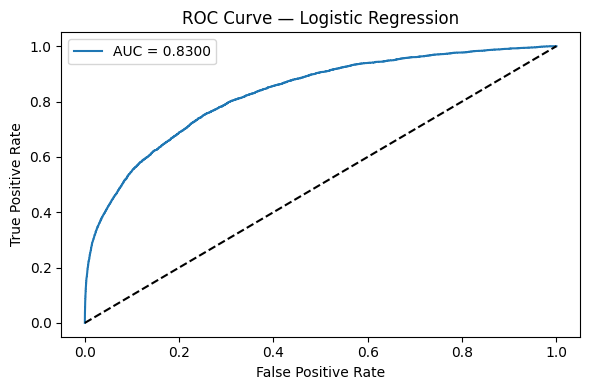

✅ Logistic Regression selesai!


In [ ]:
print("Training Logistic Regression...")
with mlflow.start_run(run_name="LogisticRegression_Baseline"):
    lr = LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        solver='saga',
        n_jobs=-1,
        random_state=42
    )
    lr.fit(X_train_scaled, y_train)

    y_pred_lr = lr.predict_proba(X_val_scaled)[:, 1]
    metrics_lr = evaluate("Logistic Regression", y_val, y_pred_lr)
    results.append(metrics_lr)

    mlflow.log_params({'model': 'LogisticRegression', 'solver': 'saga'})
    mlflow.log_metrics({k: v for k, v in metrics_lr.items() if k != 'model'})

print("Logistic Regression selesai.")

## Cell 7 — Model 2: XGBoost + Optuna Hyperparameter Tuning

**XGBoost** adalah algoritma gradient boosting yang membangun tree secara sekuensial untuk meminimalkan residual dari iterasi sebelumnya. Untuk menangani class imbalance, digunakan parameter `scale_pos_weight` yang dihitung sebagai rasio antara jumlah sampel negatif dan positif.

**Optuna** melakukan pencarian hyperparameter otomatis menggunakan TPE (Tree-structured Parzen Estimator) dengan 10 trial, memaksimalkan ROC-AUC pada validation set. Hyperparameter yang dioptimasi meliputi:
- `n_estimators`: jumlah tree (50-200)
- `max_depth`: kedalaman maksimal tree (3-6)
- `learning_rate`: kecepatan belajar (0.05-0.3)
- `subsample`: proporsi sampel per tree (0.6-1.0)
- `colsample_bytree`: proporsi fitur per tree (0.6-1.0)

In [ ]:
import xgboost as xgb

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 200),
        'max_depth'       : trial.suggest_int('max_depth', 3, 6),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.05, 0.3),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'tree_method'     : 'hist',
        'device'          : 'cuda',
        'random_state'    : 42,
        'n_jobs'          : -1,
    }
    with mlflow.start_run(run_name=f"XGB_trial_{trial.number}", nested=True):
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)], verbose=False)
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        mlflow.log_params(params)
        mlflow.log_metric("val_roc_auc", auc)
    return auc

print("Optuna tuning XGBoost (10 trials)...")

with mlflow.start_run(run_name="XGBoost_Optuna"):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_xgb, n_trials=10, show_progress_bar=True)

    print(f"\nBest ROC-AUC: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    mlflow.log_metric("best_roc_auc", study.best_value)

print("\nOptuna tuning selesai.")

Optuna tuning XGBoost (10 trials, simple)...


  0%|          | 0/10 [00:00<?, ?it/s]


✅ Best ROC-AUC: 0.9351
Best params: {'n_estimators': 94, 'max_depth': 5, 'learning_rate': 0.29676647675351325, 'subsample': 0.7581365504865276, 'colsample_bytree': 0.8539699539323469}


## Cell 8 — Training Final XGBoost & Feature Importance

Setelah mendapatkan hyperparameter terbaik dari Optuna, model final dilatih ulang dengan parameter tersebut. Hasilnya dievaluasi pada validation set menggunakan fungsi `evaluate()`, dan metrik dicatat ke MLflow.

Feature importance menunjukkan fitur mana yang paling sering digunakan model untuk membuat keputusan klasifikasi di seluruh tree. Fitur dengan skor tinggi memiliki pengaruh paling besar terhadap prediksi fraud.


  XGBoost (Tuned)
  ROC-AUC : 0.9351
  PR-AUC  : 0.6190

              precision    recall  f1-score   support

   Not Fraud       0.99      0.90      0.95    113975
       Fraud       0.23      0.82      0.36      4133

    accuracy                           0.90    118108
   macro avg       0.61      0.86      0.65    118108
weighted avg       0.97      0.90      0.92    118108



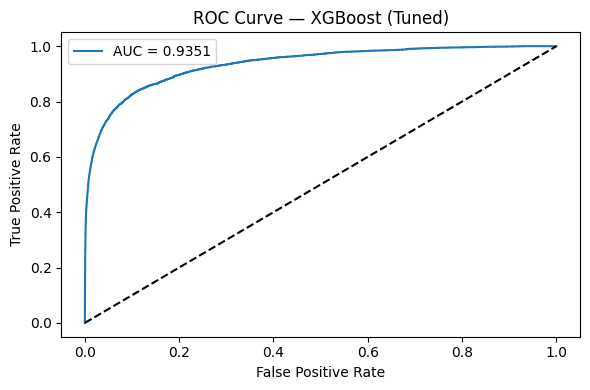

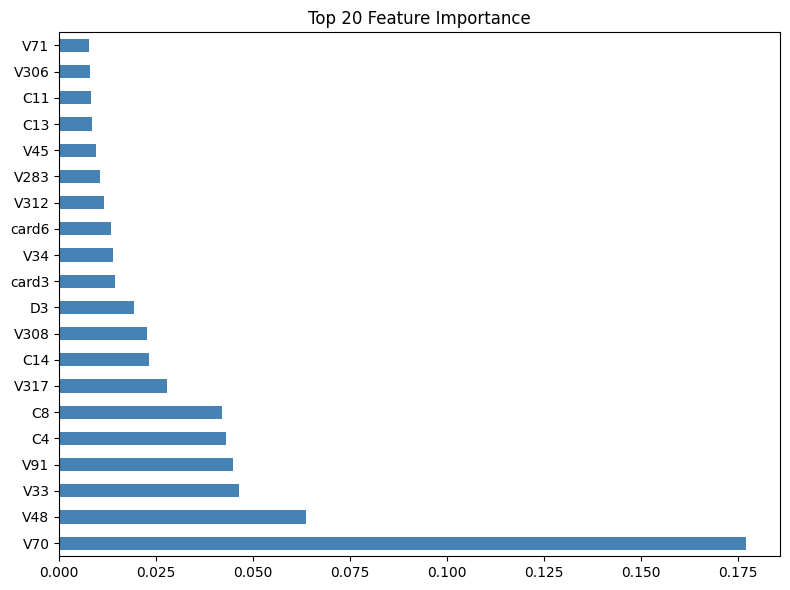

In [ ]:
best_params = study.best_params
best_params.update({
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42
})

final_xgb = xgb.XGBClassifier(**best_params)
final_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = final_xgb.predict_proba(X_val)[:, 1]
metrics_xgb = evaluate("XGBoost (Tuned)", y_val, y_pred_xgb)
results.append(metrics_xgb)

with mlflow.start_run(run_name="XGBoost_Final"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({k: v for k, v in metrics_xgb.items() if k != 'model'})

feat_imp = pd.Series(final_xgb.feature_importances_, index=feature_cols)
feat_imp.nlargest(20).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top 20 Feature Importance — XGBoost (Tuned)')
plt.tight_layout()
plt.show()

## Cell 9 — Perbandingan Semua Model

Kedua model dibandingkan berdasarkan ROC-AUC dan PR-AUC pada validation set.

Pada dataset fraud detection dengan class imbalance yang signifikan, PR-AUC sering lebih relevan daripada ROC-AUC karena mengukur seberapa baik model memprioritaskan kasus fraud yang benar-benar fraud (precision tinggi) sekaligus menangkap sebanyak mungkin fraud (recall tinggi).



=== PERBANDINGAN MODEL ===
              model  ROC_AUC   PR_AUC
Logistic Regression 0.829970 0.298172
    XGBoost (Tuned) 0.935141 0.619017


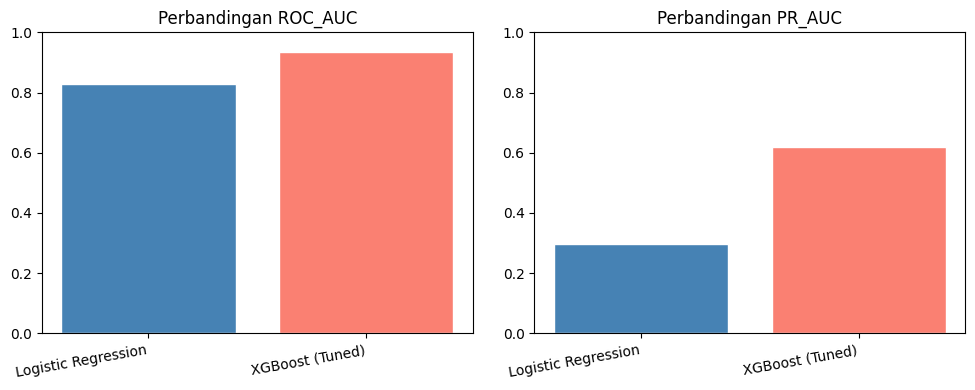

✅ Model tersimpan!


In [ ]:
results_df = pd.DataFrame(results)
print("\n=== PERBANDINGAN MODEL ===")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['ROC_AUC', 'PR_AUC']):
    ax.bar(results_df['model'], results_df[metric],
           color=['steelblue', 'salmon'], edgecolor='white')
    ax.set_title(f'Perbandingan {metric}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results_df['model'], rotation=10, ha='right')
plt.tight_layout()
plt.show()

## Cell 10 — Simpan Model ke Google Drive

Semua artifact disimpan ke Google Drive agar dapat digunakan kembali tanpa training ulang:
- `lr_model.pkl` — model Logistic Regression
- `xgb_final.pkl` — model XGBoost terbaik
- `scaler.pkl` — StandardScaler yang di-fit pada training data

Cara load ulang: `model = joblib.load('path/xgb_final.pkl')` kemudian `scaler = joblib.load('path/scaler.pkl')`


In [ ]:
import joblib, os

SAVE_PATH = '/content/drive/MyDrive/ML Dataset/models_fraud/'
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(lr,        SAVE_PATH + 'lr_model.pkl')
joblib.dump(final_xgb, SAVE_PATH + 'xgb_final.pkl')
joblib.dump(scaler,    SAVE_PATH + 'scaler.pkl')

print(f"Semua model berhasil disimpan ke: {SAVE_PATH}")
print("\n=== RINGKASAN AKHIR ===")
print(results_df.to_string(index=False))